nodes (intersections): 155196
edges (road segments): 393531


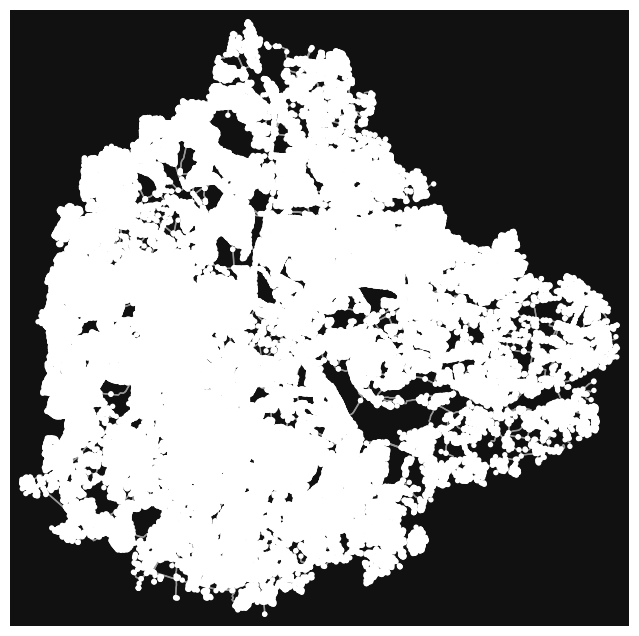

In [2]:
import osmnx as ox
import matplotlib.pyplot as plt

# Use alternate Overpass server
ox.settings.overpass_endpoint = "https://overpass.kumi.systems/api/interpreter"

# Optional: increase timeout
ox.settings.timeout = 300

roads = ox.graph_from_place(
    "Bangalore, Karnataka, India",
    network_type="drive"
)
print("nodes (intersections):", len(roads.nodes))
print("edges (road segments):", len(roads.edges))

fig, ax = ox.plot_graph(roads)
plt.show()

In [3]:
nodes_gdf, edges_gdf = ox.graph_to_gdfs(roads)
print(nodes_gdf.columns.tolist())
print(edges_gdf.columns.tolist())
print("\nEdges sample:")
print(edges_gdf)
print("\nNodes sample:")
print(nodes_gdf)

['y', 'x', 'street_count', 'highway', 'junction', 'ref', 'geometry']
['osmid', 'highway', 'lanes', 'name', 'oneway', 'reversed', 'length', 'geometry', 'maxspeed', 'ref', 'bridge', 'width', 'access', 'junction', 'tunnel', 'est_width', 'area']

Edges sample:
                                  osmid      highway lanes  \
u           v           key                                  
17327095    248007842   0      32261256  residential     2   
            305154531   0    1367650597    secondary     2   
            5354313543  0    1367650758  residential   NaN   
17327139    443224605   0     111814615      primary     2   
            309593057   0      28186701  residential   NaN   
...                                 ...          ...   ...   
13809156258 6567082805  0     699329168  residential   NaN   
13809156259 7384536840  0     789815761  residential   NaN   
            13809156258 0    1510601091  residential   NaN   
            7384536842  0     789815761  residential   NaN   

In [4]:
print("total intersections:", len(nodes_gdf))
total_length=edges_gdf['length'].sum()
print("total road length:", round(total_length/1000,2), "km")
print("road types:",edges_gdf['highway'].value_counts())

total intersections: 155196
total road length: 24239.17 km
road types: highway
residential                     327002
tertiary                         39577
secondary                        13531
living_street                     4761
primary                           4212
unclassified                      1327
trunk                             1072
primary_link                       453
trunk_link                         383
secondary_link                     365
[living_street, residential]       344
tertiary_link                      230
motorway_link                       90
motorway                            54
[residential, tertiary]             49
[residential, unclassified]         32
road                                24
busway                               4
[secondary_link, secondary]          3
[motorway_link, motorway]            3
[unclassified, tertiary]             2
[tertiary, unclassified]             2
[secondary, tertiary]                2
[living_street, tertiary

geoalchemy2


In [5]:
from sqlalchemy import create_engine
engine=create_engine("postgresql://kommamanjunathreddy@localhost:5432/gisdb")
edges_gdf.to_postgis("bangalore_roads", engine, if_exists="replace")
print("roads saved to database")

roads saved to database


In [6]:
import geopandas as gpd
roads_from_db=gpd.read_postgis("SELECT * FROM bangalore_roads", engine, geom_col="geometry")
print("roads loaded", len(roads_from_db))
print("columns:", roads_from_db.columns.tolist())

roads loaded 393531
columns: ['osmid', 'highway', 'lanes', 'name', 'oneway', 'reversed', 'length', 'geometry', 'maxspeed', 'ref', 'bridge', 'width', 'access', 'junction', 'tunnel', 'est_width', 'area']


In [7]:
primary_roads=gpd.read_postgis("SELECT * FROM bangalore_roads WHERE highway='primary'", engine, geom_col="geometry")
print("primary roads:", len(primary_roads))

primary roads: 4212


In [8]:
import folium
from folium import GeoJson
m=folium.Map(location=[12.9716, 77.5946], zoom_start=12)
folium.GeoJson(primary_roads).add_to(m)
m.save("bangalore_primary_roads.html")
print("map saved as bangalore_primary_roads.html")



map saved as bangalore_primary_roads.html


In [10]:
import osmnx as ox
place=ox.geocode_to_gdf("Bangalore, Karnataka, India")
print(place.crs)
place_metres=place.to_crs(epsg=32643)
print(place_metres.crs)
print(place.geometry.values[0].centroid)
print(place_metres.geometry.values[0].centroid)

epsg:4326
EPSG:32643
POINT (77.60297894732507 12.976329803066292)
POINT (782386.1455604363 1435958.3391683055)


In [11]:
area_sqm=place_metres.geometry.area.values[0]
print(area_sqm/1_000_000, "square km")

717.2092595977484 square km


In [12]:
roads_from_db1=gpd.read_postgis("SELECT * FROM bangalore_roads WHERE highway='primary'", engine, geom_col="geometry")
roads_from_db_km=roads_from_db1.to_crs(epsg=32643)
total_length_km=roads_from_db_km.geometry.length.sum()/1000
print("total road length:", round(total_length_km,2), "km")

total road length: 463.26 km


In [13]:
import osmnx as ox

# Reset to default settings
ox.settings.overpass_url = "https://overpass-api.de/api/interpreter"
ox.settings.requests_timeout = 300
ox.settings.requests_kwargs = {}  # remove SSL bypass

# Try fetching hospitals
hospitals = ox.features_from_place(
    "Indiranagar, Bangalore, India",
    tags={"amenity": "hospital"}
)

print("Total hospitals:", len(hospitals))
print("Geometry types:", hospitals.geometry.type.value_counts())

Total hospitals: 12
Geometry types: Point      7
Polygon    5
Name: count, dtype: int64


In [14]:
hospital_points=hospitals[hospitals.geometry.type=="Point"]
hospital_points.to_postgis("bangalore_indiranagar_hospitals", engine, if_exists="replace")
print("hospital points saved to database")

hospital points saved to database


In [15]:
hospitals_metres=hospital_points.to_crs(epsg=32643)
hospitals_buffer=hospitals_metres.geometry.buffer(500)

In [16]:
print(hospitals_buffer.geom_type.value_counts())
print(round(hospitals_buffer.area.values[0]/1_000_000, 2), "square km")

Polygon    7
Name: count, dtype: int64
0.78 square km


In [17]:
hospital_buffer_gdf=gpd.GeoDataFrame(geometry=hospitals_buffer, crs="EPSG:32643")
hospital_normal=hospital_buffer_gdf.to_crs(epsg=4326)
folium.GeoJson(hospital_normal).add_to(m)
m.save("bangalore_primary_roads_and_hospitals.html")
print("map with hospitals saved as bangalore_primary_roads_and_hospitals.html")

map with hospitals saved as bangalore_primary_roads_and_hospitals.html


In [18]:
import pandas as pd
import geopandas as gpd

area_names = [
    "Indiranagar, Bangalore, India",
    "Whitefield, Bangalore, India",
    "Hebbal, Bangalore, India",
    "Yelahanka, Bangalore, India",
    "Electronic City, Bangalore, India",
    "Marathahalli, Bangalore, India",
    "BTM Layout, Bangalore, India",
    "HSR Layout, Bangalore, India"
]

gdfs = []
for area in area_names:
    try:
        gdf = ox.geocode_to_gdf(area)
        gdf['area_name'] = area.split(',')[0]  # add name column
        gdfs.append(gdf)
        print(f"✅ {area}")
    except:
        print(f"❌ No polygon for {area}")

# Combine all successful ones
neighbourhoods = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs="EPSG:4326"
)
print("\nTotal neighbourhoods got:", len(neighbourhoods))

✅ Indiranagar, Bangalore, India
✅ Whitefield, Bangalore, India
✅ Hebbal, Bangalore, India
✅ Yelahanka, Bangalore, India
✅ Electronic City, Bangalore, India
✅ Marathahalli, Bangalore, India
❌ No polygon for BTM Layout, Bangalore, India
✅ HSR Layout, Bangalore, India

Total neighbourhoods got: 7


In [19]:
from sqlalchemy import create_engine
engine=create_engine("postgresql://kommamanjunathreddy@localhost:5432/gisdb")
neighbourhoods.to_postgis("bangalore_neughbourhoods",engine, if_exists="replace")
print("neighbourhoods saved to database")

neighbourhoods saved to database


In [20]:
results=gpd.sjoin(hospitals,neighbourhoods,how="left",predicate="intersects")

In [21]:
print(results[['name_left', 'area_name']])

                                                        name_left    area_name
element id                                                                    
node    3556103531                  ALDOS Medical Service Pvt LTD  Indiranagar
        4445578787   Dr. Bhargavi Reddy Women & Children Hospital  Indiranagar
        4445586944                       Axon Speciality Hospital  Indiranagar
        5297145822       Nethradhama Superspeciality Eye Hospital  Indiranagar
        6944707745       Chinmaya Narayana Super Specialty Centre  Indiranagar
        7976310624                           Chinmaya Hrudayalaya  Indiranagar
        11272209797                               Ayaans Hospital  Indiranagar
way     35133587                        Chinmaya Mission Hospital  Indiranagar
        135266042                 Indiranagar Government Hospital  Indiranagar
        135266057                              Isolation Hospital  Indiranagar
        347120731                   MS Diabetes Spec

In [22]:
print(results.columns.tolist())

['geometry', 'amenity', 'name_left', 'addr:city', 'addr:postcode', 'addr:street', 'healthcare', 'phone', 'website', 'addr:housenumber', 'addr:district', 'addr:full', 'addr:state', 'addr:subdistrict', 'email', 'operator:type', 'source', 'check_date', 'healthcare:speciality', 'description', 'name:kn', 'wheelchair', 'emergency', 'toilets:wheelchair', 'building', 'building:levels', 'index_right', 'bbox_west', 'bbox_south', 'bbox_east', 'bbox_north', 'place_id', 'osm_type', 'osm_id', 'lat', 'lon', 'class', 'type', 'place_rank', 'importance', 'addresstype', 'name_right', 'display_name', 'area_name']


In [23]:
counts=results.groupby('area_name')['name_left'].count()

In [24]:
print(counts)

area_name
Indiranagar    12
Name: name_left, dtype: int64


In [25]:
indiranagar=neighbourhoods[neighbourhoods['area_name']=='Indiranagar']
clipped_roads=gpd.clip(edges_gdf, indiranagar)
print(len(clipped_roads))
print(len(edges_gdf))

1151
393531


In [26]:
print(clipped_roads.crs)
print(edges_gdf.crs)

epsg:4326
epsg:4326


In [27]:
centroid=indiranagar.geometry.values[0].centroid
print(centroid.x)
print(centroid.y)

77.643174805828
12.981529291228759


In [28]:
def road_style(feature):
    highway = feature['properties'].get('highway', '')
    if highway == 'primary':
        return {'color': 'red', 'weight': 4, 'dashArray': ''}
    elif highway == 'secondary':
        return {'color': 'orange', 'weight': 3, 'dashArray': '5,5'}
    elif highway == 'tertiary':
        return {'color': 'yellow', 'weight': 2, 'dashArray': '3,3'}
    else:
        return {'color': 'blue', 'weight': 1, 'dashArray': ''}


In [45]:
m1=folium.Map(location=[centroid.y, centroid.x], zoom_start=14)
folium.GeoJson(
    clipped_roads,
    name="Roads",
    style_function=road_style
).add_to(m1)
folium.GeoJson(hospital_normal,name="Buffered hospitals", style_function=lambda x:{'color': 'green', 'weight':2, 'fillcolor':'green','fillOpacity':0.2}).add_to(m1)
folium.GeoJson(indiranagar,name="Boundary",
               style_function=lambda x:{'color': 'red', 'weight': 6}).add_to(m1)
# Create a group with a name
hospital_group = folium.FeatureGroup(name="Hospitals")

# Add CircleMarkers to the GROUP instead of map
for idx, row in hospital_points.iterrows():
    html=f"""
       <div style="font-family":Times New Roman; width:200px;">
       <h4 style="color:darkblue; margin-bottom: 5px;">
       🏥 {row['name']}
</h4>
<hr>
<b>Type:</b>{row['amenity']}</br>
<b>Phone:</b>{row.get('phone','N/A')}</br>
<b>Area:</b> Indiranagar
</div>
    """
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=8,
        color='darkblue',
        fill=True,
        fill_color='yellow',
        fill_opacity=0.7,
        tooltip=row['name'],
        popup=folium.Popup(html,max_width=250)
    ).add_to(hospital_group)  # ← add to group, not m1

from folium.plugins import MarkerCluster
hospital_cluster = MarkerCluster(name="Hospital Cluster").add_to(m1)
for idx, row in hospital_points.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        tooltip=row['name'],

    ).add_to(hospital_cluster)  # add to cluster, not m1


from folium.plugins import HeatMap
heat_data = [[row.geometry.y, row.geometry.x] for idx, row in hospital_points.iterrows()]
HeatMap(heat_data, name="Hospital Heatmap", radius=15, min_opacity=0.6, blur=10).add_to(m1)
# Add group to map
hospital_group.add_to(m1)


folium.Choropleth(
    geo_data=neighbourhoods,
    data=hospital_count,
    columns=['area_name', 'hospital_count'],
    key_on='feature.properties.area_name',
    fill_color='BuPu',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Hospital Count per Neighbourhood',
    name='Choropleth'
).add_to(m1)
from folium.plugins import MiniMap, Fullscreen
MiniMap(toggle_display=True, position='bottomleft').add_to(m1)
Fullscreen(position='topleft', title='View Fullscreen', title_cancel='Exit Fullscreen').add_to(m1)
folium.LayerControl().add_to(m1)
m1.save("indiranagar_roads.html")
print("map of Indiranagar roads saved as indiranagar_roads.html")

map of Indiranagar roads saved as indiranagar_roads.html


In [40]:
import pandas as pd
hospital_count=results.groupby('area_name')['name_left'].count().reset_index()
print(hospital_count)
hospital_count.columns=['area_name','hospital_count']
print(hospital_count)

     area_name  name_left
0  Indiranagar         12
     area_name  hospital_count
0  Indiranagar              12


In [31]:
merged=neighbourhoods.dissolve()
print(len(neighbourhoods))
print(len(merged))

7
1


In [32]:
neighbourhoods['city']='bangalore'
merged_by_city=neighbourhoods.dissolve(by='city')
print(merged_by_city)
print(len(merged_by_city))

                                                    geometry  bbox_west  \
city                                                                      
bangalore  MULTIPOLYGON (((77.64859 12.84922, 77.64894 12...  77.630836   

           bbox_south  bbox_east  bbox_north   place_id  osm_type    osm_id  \
city                                                                          
bangalore   12.968418  77.656772   12.993814  423716319  relation  19883335   

                 lat        lon     class            type  place_rank  \
city                                                                    
bangalore  12.981068  77.644364  boundary  administrative          20   

           importance addresstype         name  \
city                                             
bangalore    0.133404      suburb  Indiranagar   

                                                display_name    area_name  
city                                                                       
bangalore  In

In [33]:
import folium

m = folium.Map(location=[12.9716, 77.5946], zoom_start=11)

# Add original 7 neighbourhoods - blue
folium.GeoJson(
    neighbourhoods,
    style_function=lambda x: {'color': 'blue', 'fillOpacity': 0.3}
).add_to(m)

# Add dissolved single polygon - red
folium.GeoJson(
    merged_by_city,
    style_function=lambda x: {'color': 'red', 'fillOpacity': 0.1}
).add_to(m)

m.save("dissolve_comparison.html")

In [35]:
from shapely.geometry import Point
city_centre=Point(77.5946, 12.9716)
hospital_points_m=hospital_points.to_crs(epsg=32643)
city_centr_m=gpd.GeoSeries([city_centre],crs="epsg:4326").to_crs(epsg=32643)
hospital_points_m['distance_Km']=hospital_points_m.geometry.distance(city_centr_m[0])/1000
print(hospital_points_m[['name','distance_Km']])


                                                             name  distance_Km
element id                                                                    
node    3556103531                  ALDOS Medical Service Pvt LTD     4.879037
        4445578787   Dr. Bhargavi Reddy Women & Children Hospital     5.710603
        4445586944                       Axon Speciality Hospital     5.595639
        5297145822       Nethradhama Superspeciality Eye Hospital     5.732355
        6944707745       Chinmaya Narayana Super Specialty Centre     5.618429
        7976310624                           Chinmaya Hrudayalaya     5.616280
        11272209797                               Ayaans Hospital     5.369149


In [36]:
nearest_hospital=hospital_points_m['distance_Km'].idxmin()
print("Nearest hospital:", hospital_points_m.loc[nearest_hospital,'name'], hospital_points_m.loc[nearest_hospital,'distance_Km'],"Km")

Nearest hospital: ALDOS Medical Service Pvt LTD 4.879037321415637 Km


In [37]:
farthest_hospital=hospital_points_m['distance_Km'].idxmax()
print("Farthest hospital:",hospital_points_m.loc[farthest_hospital,'name'])


Farthest hospital: Nethradhama Superspeciality Eye Hospital
